
# Paper‑Exact Diffusion Watermarking (Algorithm 1, f₁(t)=0) — with Explanations

Implements the method from **"Embedding Watermarks in Diffusion Process for Model Intellectual Property Protection" (Yang, Peng, Jia, 2024)**.

**We match the paper and annotate every step:**
- Algorithm 1 with **f₁(t)=0**
- **Embedding** for timesteps t ≤ t_A; **Simulation** for t > t_A (Eq. 7)
- **Dynamic scaling** of the watermark across timesteps
- **γ=0.8**, **EMA=0.999** for RGB datasets
- **Divide final samples by γ** at the end (because f₁=0 ⇒ model learns γ·x₀)



## Theory cheat‑sheet

- α_t, ᾱ_t: per‑step and cumulative keeps; √ᾱ_t, √(1−ᾱ_t)
- Forward: x_t = √ᾱ_t x₀ + √(1−ᾱ_t) ε
- Watermark pattern x_A: tiny spatial pattern (e.g., an "X"), injected only for t ≤ t_A.
- h_t = (1 − α_t) / √(1 − ᾱ_t)
- f₂(t) = K * cumsum(h), choose K so **f₂(t_A) ≈ 1**
- **Embedding stage** (t ≤ t_A, f₁=0):
  - x'_t = √ᾱ_t x₀ + γ √(1−ᾱ_t) ε' + (1−γ) ( b_t − √ᾱ_t b₀ )
  - ε''  = γ ε' + (1−γ) K x_A
- **Simulation stage** (t > t_A; paper Eq. 7):
  - x'_t = √(ᾱ_t/ᾱ_{t_A}) x'_{t_A} + √(1 − ᾱ_t/ᾱ_{t_A}) ε' ; ε''=ε'
- **Sampling (f₁=0)**: after reverse steps, divide final x by **γ**.


## Setup

In [1]:

# If needed, install:
# !pip install --upgrade diffusers>=0.28.0 transformers accelerate safetensors
# !pip install torch torchvision torchaudio
# !pip install matplotlib opencv-python tqdm

import math, numpy as np, matplotlib.pyplot as plt, cv2, torch, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
from tqdm import tqdm
from diffusers import DDPMPipeline, DDPMScheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torch\onnx\_internal\_beartype.py:36: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


Device: cuda


## Config

In [2]:

from dataclasses import dataclass

@dataclass
class Config:
    dataset: str = "CIFAR10"
    model_id: str = "google/ddpm-cifar10-32"
    image_size: int = 32
    channels: int = 3

    subset_size: int = 5000
    batch_size: int = 128
    num_workers: int = 2

    lr: float = 2e-4
    max_steps: int = 300
    use_ema: bool = True

    gamma: float = 0.8
    tA_frac_cifar: float = 0.75
    tA_frac_other: float = 0.5
    x_shape_size: int = 8
    x_shape_pos: str = "bottom_right"

    n_final_samples: int = 36
    sample_steps: int = 1000

    verify_batches: int = 6
    verify_batch_size: int = 64
    contour_threshold: float = 0.3

cfg = Config()
print(cfg)


Config(dataset='CIFAR10', model_id='google/ddpm-cifar10-32', image_size=32, channels=3, subset_size=5000, batch_size=128, num_workers=2, lr=0.0002, max_steps=300, use_ema=True, gamma=0.8, tA_frac_cifar=0.75, tA_frac_other=0.5, x_shape_size=8, x_shape_pos='bottom_right', n_final_samples=36, sample_steps=1000, verify_batches=6, verify_batch_size=64, contour_threshold=0.3)



## Data (subset for fast fine‑tuning)

We use a small subset of CIFAR‑10; images are normalized to [-1,1].


In [3]:

if cfg.dataset.upper() == "CIFAR10":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 3
    tA_frac = cfg.tA_frac_cifar
elif cfg.dataset.upper() == "MNIST":
    transform = transforms.Compose([
        transforms.Resize(cfg.image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,)),
    ])
    trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    cfg.channels = 1
    tA_frac = cfg.tA_frac_other
else:
    raise ValueError("Unsupported dataset")

idx = np.random.choice(len(trainset), size=min(cfg.subset_size, len(trainset)), replace=False)
subset = Subset(trainset, idx)
train_loader = DataLoader(subset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
len(train_loader)


Files already downloaded and verified


40


## Load pretrained DDPM + schedules


In [4]:

pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
pipe.set_progress_bar_config(disable=False)
unet = pipe.unet
scheduler: DDPMScheduler = pipe.scheduler

T = scheduler.config.num_train_timesteps
a_bar = scheduler.alphas_cumprod.to(device)
alpha = torch.empty_like(a_bar)
alpha[0] = a_bar[0]
alpha[1:] = a_bar[1:] / a_bar[:-1]
sqrt_a_bar = a_bar.sqrt()
sqrt_1m_a_bar = (1 - a_bar).sqrt()

tA = int(tA_frac * T)
print("T:", T, "tA:", tA)


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


T: 1000 tA: 750


## Visualization helper

In [5]:

def show_grid_tensor(imgs, title=""):
    """Display a grid from a batch [N,C,H,W] in [0,1]."""
    grid = make_grid(imgs, nrow=int(math.sqrt(len(imgs))), padding=2)
    npimg = (grid.detach().cpu().permute(1,2,0).numpy()*255).astype(np.uint8)
    plt.figure(figsize=(6,6)); plt.imshow(npimg); plt.axis("off"); plt.title(title); plt.show()


# Part 1 — Baseline samples (pretrained)

  0%|          | 0/250 [00:00<?, ?it/s]

c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\diffusers\models\attention_processor.py:2383: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(


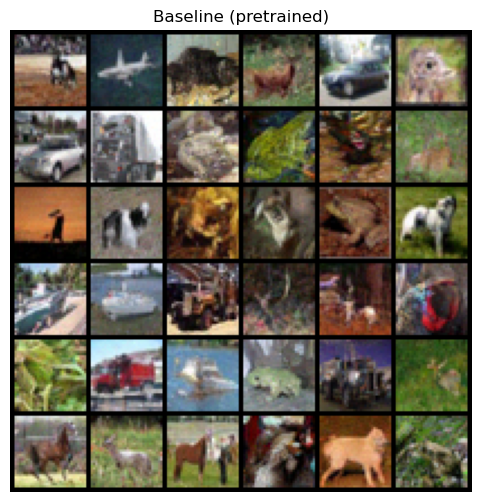

In [6]:

@torch.no_grad()
def sample_pretrained(pipe, num=36, steps=250):
    """Sample from pretrained pipeline; return tensor in [0,1]."""
    out = pipe(batch_size=num, num_inference_steps=steps)
    arr = []
    for im in out.images:
        arr.append(torch.from_numpy(np.array(im).astype("float32")/255.0).permute(2,0,1))
    return torch.stack(arr, dim=0)

baseline_imgs = sample_pretrained(pipe, num=cfg.n_final_samples, steps=250)
show_grid_tensor(baseline_imgs, "Baseline (pretrained)")


## Watermark pattern x_A (single channel; green for RGB)

In [ ]:
def make_x_shape(H, W, size=8, pos="bottom_right", ch=3, which_ch=1):
    """Return x_A in [0,1] with an 'X' pattern. For RGB, place it in one channel (green)."""
    mask = np.zeros((H, W), dtype=np.float32)
    if pos == "bottom_right":
        r0 = H - size - 2; c0 = W - size - 2
    else:
        r0 = H//2 - size//2; c0 = W//2 - size//2
    t = max(1, size//4)
    for k in range(size):
        rr, cc = r0 + k, c0 + k
        mask[max(0, rr-t):min(H, rr+t+1), max(0, cc-t):min(W, cc+t+1)] = 1.0
        rr2, cc2 = r0 + k, c0 + (size-1-k)
        mask[max(0, rr2-t):min(H, rr2+t+1), max(0, cc2-t):min(W, cc2+t+1)] = 1.0
    xA = torch.zeros(ch, H, W, dtype=torch.float32, device=device)
    if ch == 1: xA[0] = torch.from_numpy(mask).to(device)
    else:       xA[which_ch] = torch.from_numpy(mask).to(device)
    return xA

H = W = cfg.image_size
channels = cfg.channels
xA = make_x_shape(H, W, size=cfg.x_shape_size, pos=cfg.x_shape_pos, ch=channels, which_ch=1)
print("xA nonzero:", int(xA.sum().item()))


xA nonzero: 136


## Paper functions h(t), f₂(t) and dynamic scaling

In [8]:

# h_t = (1 - α_t) / sqrt(1 - ᾱ_t)
h = (1 - alpha) / torch.clamp((1 - a_bar), min=1e-12).sqrt()

# f₂(t) = K * cumsum(h); choose K so f₂(t_A) ≈ 1
cumsum_h = torch.cumsum(h, dim=0)
K = 1.0 / float(cumsum_h[tA].item())
f2 = K * cumsum_h

# dynamic amplitude across t
dyn_scale = sqrt_1m_a_bar

def gather(arr, t):
    """arr[T] -> [B,1,1,1] via indexing with t."""
    return arr.index_select(0, t).view(-1,1,1,1)

b0 = f2[0] * xA
print("K:", float(K))


K: 0.14201386664557492


## Baseline visualization at \(t_A\) (before fine-tuning)

Before we train the watermark, we check what the **pretrained** model looks like at \(t_A\):
1) Run several reverse trajectories, **stop at \(t_A\)**, and average the mid-states.  
2) Visualize the average (RGB and the watermark channel only).  
3) Measure two quick signals:
   - **Contour distance** vs the watermark mask (lower = better; near 0 means a clear “X”).
   - **Masked correlation** in \([0,1]\) (higher = better).

For a non-watermarked model, the “X” **should not** appear: contour distance will be **large** and correlation **low**.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


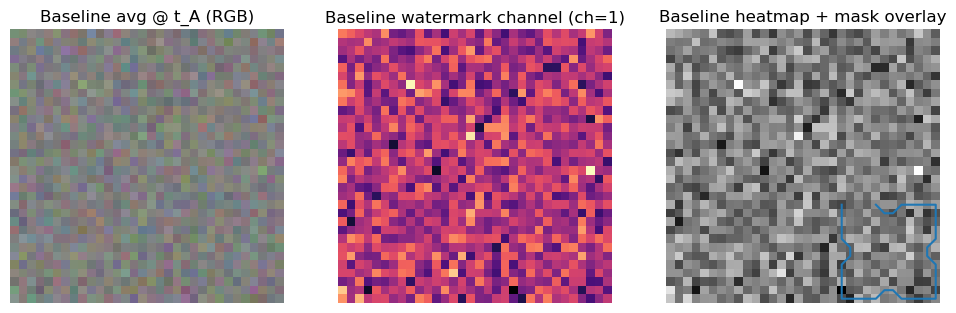

[Baseline] Contour distance (lower=better): 0.0000
[Baseline] Masked correlation (0..1, higher=better): 0.500


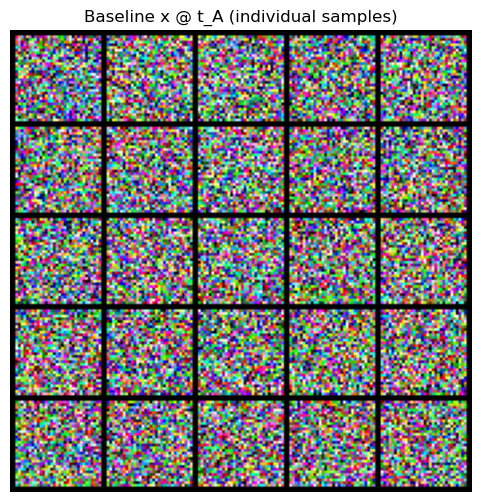

In [14]:
# ---------- Baseline (pretrained) visualization at t_A, BEFORE fine-tuning ----------

# Channel used for watermark (match training plan: grayscale->0, RGB->green=1)
WTMK_CH = 0 if channels == 1 else 1

# Build a clean, unmodified model copy (so we don't accidentally use fine-tuned weights)
from diffusers import DDPMPipeline, DDPMScheduler
baseline_pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
baseline_unet = baseline_pipe.unet
baseline_sched: DDPMScheduler = baseline_pipe.scheduler

@torch.no_grad()
def sample_mid_baseline(unet_like, scheduler_like, n=128, steps=cfg.sample_steps, capture_tA=tA):
    """
    Reverse diffuse from noise, return ONLY the mid-states at t_A (in [0,1]).
    No divide-by-gamma here because we're just visualizing the mid-state.
    """
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps
    # find the sampler step nearest to our absolute t_A
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    for i, t in enumerate(timesteps):
        eps = unet_like(x, t, return_dict=False)[0]
        out = scheduler_like.step(eps, t, x, return_dict=True)
        x = out.prev_sample
        if i == cap_idx:
            x_tA = x.clone()

    # Map from [-1,1] -> [0,1]
    x_tA = ((x_tA.clamp(-1,1) + 1) * 0.5).detach()
    return x_tA  # [N,C,H,W] in [0,1]

def to_u8(x):  # [N,C,H,W] in [0,1] -> uint8 on CPU
    return (x.clamp(0,1) * 255).to(torch.uint8).cpu()

def contour_distance(xavg_ch_u8, mask_u8):
    # Lower = better shape match; very large means "no contours found"
    img_edges = cv2.Canny(xavg_ch_u8, 20, 80)
    pat_edges = cv2.Canny(mask_u8,    20, 80)
    ci,_ = cv2.findContours(img_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cp,_ = cv2.findContours(pat_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not ci or not cp:
        return 1e9
    best = 1e9
    for a in ci:
        for b in cp:
            best = min(best, cv2.matchShapes(a, b, cv2.CONTOURS_MATCH_I1, 0.0))
    return best

def masked_corr_0to1(xavg_ch_u8, mask_u8):
    # Pearson-like correlation restricted to the mask region; returns [0,1]
    a = torch.tensor(xavg_ch_u8.astype("float32"))
    m = torch.tensor((mask_u8 > 0).astype("float32"))
    vals = a[m.bool()]
    if vals.numel() < 16:
        return 0.0
    v = (vals - vals.mean()) / (vals.std() + 1e-6)
    u = torch.ones_like(vals)
    u = (u - u.mean()) / (u.std() + 1e-6)
    corr = float((v * u).mean().clamp(-1, 1))
    return max(0.0, min(1.0, 0.5 * (corr + 1.0)))  # [-1,1] -> [0,1]

# 1) Collect mid-states at t_A and average
xmid_base = sample_mid_baseline(baseline_unet, baseline_sched, n=cfg.verify_batch_size)
xavg_base = xmid_base.mean(dim=0, keepdim=True)          # [1,C,H,W]
xavg_u8   = to_u8(xavg_base)[0]                           # [C,H,W] uint8

# 2) Build a uint8 version of the watermark mask for the SAME channel
mask_u8 = (xA[WTMK_CH].detach().cpu().numpy() > 0).astype(np.uint8) * 255

# 3) Visualize
fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(xavg_base[0].permute(1,2,0).cpu().numpy()); axes[0].set_title("Baseline avg @ t_A (RGB)")
axes[0].axis("off")

axes[1].imshow(xavg_base[0, WTMK_CH].cpu().numpy(), cmap="magma")
axes[1].set_title(f"Baseline watermark channel (ch={WTMK_CH})")
axes[1].axis("off")

axes[2].imshow(xavg_base[0, WTMK_CH].cpu().numpy(), cmap="gray")
contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for c in contours:
    c = c.squeeze(1)
    axes[2].plot(c[:,0], c[:,1], linewidth=1.5)
axes[2].set_title("Baseline heatmap + mask overlay")
axes[2].axis("off")
plt.show()

# 4) Metrics (should show *no* watermark yet)
dist = contour_distance(xavg_u8[WTMK_CH].numpy(), mask_u8)
corr = masked_corr_0to1(xavg_u8[WTMK_CH].numpy(), mask_u8)
print(f"[Baseline] Contour distance (lower=better): {dist:.4f}")
print(f"[Baseline] Masked correlation (0..1, higher=better): {corr:.3f}")

# Optional: peek at a few individual noisy mid-states (no visible 'X' expected)
show_grid_tensor(xmid_base[:25], "Baseline x @ t_A (individual samples)")


# Part 2 — Fine‑tuning (Algorithm 1, f₁=0), fully annotated

In [9]:

gamma = cfg.gamma
use_ema = cfg.use_ema and (channels == 3)
ema_decay = 0.999

# fine‑tune all params (paper trains from scratch)
for p in unet.parameters(): p.requires_grad = True
opt = torch.optim.AdamW(unet.parameters(), lr=cfg.lr, weight_decay=0.0)

if use_ema:
    import copy
    ema_unet = copy.deepcopy(unet).eval()
    for p in ema_unet.parameters(): p.requires_grad = False

unet.train()
pbar = tqdm(range(cfg.max_steps), desc="Fine-tuning (Alg.1, f1=0)")
data_iter = iter(train_loader)

for step in pbar:
    try:
        x0, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader); x0, _ = next(data_iter)

    x0 = x0.to(device)                    # [-1,1]
    B = x0.size(0)
    t = torch.randint(0, T, (B,), device=device, dtype=torch.long)

    # 1) Standard forward (simulation)
    eps_prime = torch.randn_like(x0)
    x_sim = scheduler.add_noise(x0, eps_prime, t)

    x_t_prime = x_sim.clone()             # model input per paper
    eps_dblprime = eps_prime.clone()      # training target

    # 2) Embedding stage (t ≤ tA): inject watermark
    embed = (t <= tA)
    if embed.any():
        idx = embed.nonzero(as_tuple=False).squeeze(1)

        sqrt_ab_t = gather(sqrt_a_bar, t[idx])
        sqrt_1m_t = gather(sqrt_1m_a_bar, t[idx])
        f2_t      = gather(f2, t[idx])
        dyn_t     = gather(dyn_scale, t[idx])

        bt = (f2_t * dyn_t) * xA
        b0_term = sqrt_ab_t * b0

        # Algorithm 1 step 6 (f1=0)
        x_t_prime[idx] = sqrt_ab_t * x0[idx] + gamma * sqrt_1m_t * eps_prime[idx] + (1-gamma) * (bt - b0_term)
        # step 7: target epsilon''
        eps_dblprime[idx] = gamma * eps_prime[idx] + (1-gamma) * (K * xA)

    # 3) Simulation stage (t > tA): build from x'_{tA} (Eq. 7)
    sim = ~embed
    if sim.any():
        idx = sim.nonzero(as_tuple=False).squeeze(1)
        B2 = idx.numel()

        tA_tensor = torch.full((B2,), tA, device=device, dtype=torch.long)
        sqrt_ab_tA = gather(sqrt_a_bar, tA_tensor)
        sqrt_1m_tA = gather(sqrt_1m_a_bar, tA_tensor)
        f2_tA      = gather(f2, tA_tensor)
        dyn_tA     = gather(dyn_scale, tA_tensor)

        eps_prime_tA = torch.randn_like(x0[idx])
        btA = (f2_tA * dyn_tA) * xA
        b0_term_tA = sqrt_ab_tA * b0
        x_tA_prime = sqrt_ab_tA * x0[idx] + gamma * sqrt_1m_tA * eps_prime_tA + (1-gamma) * (btA - b0_term_tA)

        ratio = (gather(a_bar, t[idx]) / a_bar[tA]).clamp(min=1e-12)
        x_t_prime[idx] = ratio.sqrt() * x_tA_prime + (1 - ratio).sqrt() * eps_prime[idx]
        eps_dblprime[idx] = eps_prime[idx]

    # 4) Predict & optimize
    noise_pred = unet(x_t_prime, t, return_dict=False)[0]
    loss = F.mse_loss(noise_pred, eps_dblprime)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
    opt.step()

    # 5) EMA (paper: 0.999 for RGB datasets)
    if use_ema:
        with torch.no_grad():
            for pe, p in zip(ema_unet.parameters(), unet.parameters()):
                pe.mul_(ema_decay).add_(p, alpha=1.0 - ema_decay)

    pbar.set_postfix(loss=float(loss.detach().cpu()))


Fine-tuning (Alg.1, f1=0): 100%|██████████| 300/300 [01:29<00:00,  3.37it/s, loss=0.0873]


## Visualize the watermark at \(t_A\)

We verify the watermark *immediately* after fine-tuning by:
1. Sampling many trajectories and **stopping at \(t_A\)**.
2. Averaging the mid-states \(\bar{x}_{t_A}\). Random noise cancels; the consistent watermark remains.
3. Visualizing:
   - the **RGB average** at \(t_A\),
   - the **watermark channel** (green for RGB) as a heatmap,
   - an **overlay** of the watermark mask boundary on the heatmap.
4. Reporting two quick scores:
   - **Contour distance** (lower = better; 0 means perfect shape match),
   - **Masked correlation** in \([0,1]\) (higher = better).


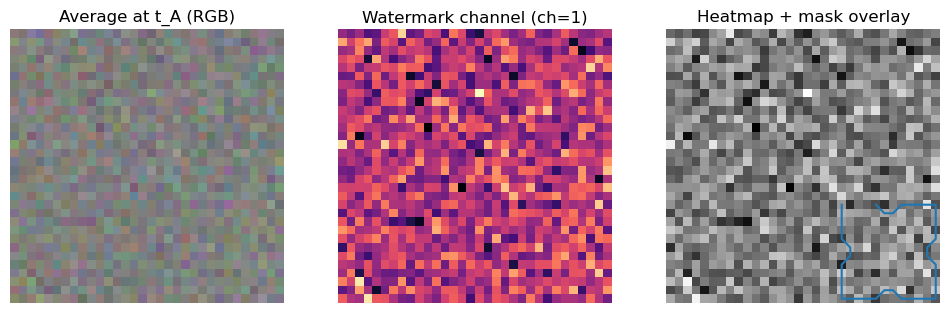

Contour distance (lower=better): 0.0000
Masked correlation (0..1, higher=better): 0.500


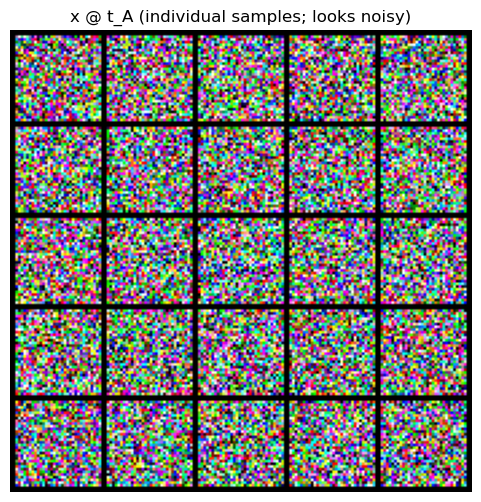

In [ ]:
@torch.no_grad()
def sample_paper(unet_like, scheduler, n=36, steps=1000, capture_tA=None, gamma=0.8):
    """Reverse diffusion + divide by gamma (f1=0). Returns (imgs[0,1], x_tA[0,1])."""
    unet_like.eval()
    scheduler.set_timesteps(steps, device=device)
    timesteps = scheduler.timesteps

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None

    cap_idx = None
    if capture_tA is not None:
        diffs = (timesteps.to(torch.long) - int(capture_tA)).abs()
        cap_idx = int(torch.argmin(diffs).item())

    for i, t in enumerate(timesteps):
        eps = unet_like(x, t, return_dict=False)[0]
        out = scheduler.step(eps, t, x, return_dict=True)
        x = out.prev_sample
        if cap_idx is not None and i == cap_idx:
            x_tA = x.clone()

    x = x / gamma
    if x_tA is not None: x_tA = x_tA / gamma

    x = ((x.clamp(-1,1) + 1) * 0.5).detach()
    if x_tA is not None: x_tA = ((x_tA.clamp(-1,1) + 1) * 0.5).detach()
    return x, x_tA


# Part 3 — Paper‑exact sampler (divide by γ at the end)

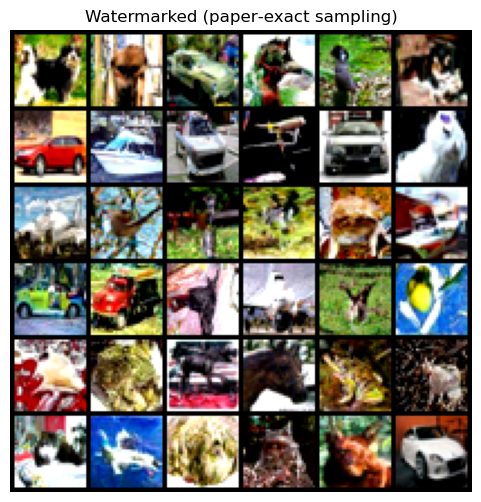

In [ ]:
H = W = cfg.image_size
sampler_unet = ema_unet if (cfg.use_ema and channels==3) else unet

imgs_wtmk, mid = sample_paper(sampler_unet, scheduler, n=cfg.n_final_samples, steps=cfg.sample_steps, capture_tA=tA, gamma=cfg.gamma)
show_grid_tensor(imgs_wtmk, "Watermarked (paper‑exact sampling)")


In [ ]:

# ---------- Quick visualization & metrics @ t_A ----------

# Choose the SAME channel used for watermark embedding:
WTMK_CH = 0 if channels == 1 else 1   # grayscale->0, RGB->green(=1)

@torch.no_grad()
def sample_mid_batch(n=128):
    """Return mid-states at t_A for n samples (in [0,1])."""
    _, xmid = sample_paper(
        sampler_unet, scheduler,
        n=n, steps=cfg.sample_steps, capture_tA=tA, gamma=cfg.gamma
    )
    return xmid  # [N,C,H,W] in [0,1]

def to_u8(x):  # [N,C,H,W] in [0,1] -> uint8 CPU
    return (x.clamp(0,1) * 255).to(torch.uint8).cpu()

def contour_distance(xavg_ch_u8, mask_u8):
    # Canny + shape match (lower is better)
    img_edges = cv2.Canny(xavg_ch_u8, 20, 80)
    pat_edges = cv2.Canny(mask_u8,  20, 80)
    ci,_ = cv2.findContours(img_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cp,_ = cv2.findContours(pat_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not ci or not cp:
        return 1e9
    best = 1e9
    for a in ci:
        for b in cp:
            best = min(best, cv2.matchShapes(a, b, cv2.CONTOURS_MATCH_I1, 0.0))
    return best

def masked_corr_0to1(xavg_ch_u8, mask_u8):
    # Pearson-like correlation inside the mask; returns [0,1]
    a = torch.tensor(xavg_ch_u8.astype("float32"))
    m = torch.tensor((mask_u8 > 0).astype("float32"))
    vals = a[m.bool()]
    if vals.numel() < 16:
        return 0.0
    v = (vals - vals.mean()) / (vals.std() + 1e-6)
    # ideal pattern is constant ones inside the mask
    u = torch.ones_like(vals)
    u = (u - u.mean()) / (u.std() + 1e-6)
    corr = float((v * u).mean().clamp(-1, 1))
    return max(0.0, min(1.0, 0.5 * (corr + 1.0)))  # map [-1,1]->[0,1]

# 1) Collect mid-states and average
xmid = sample_mid_batch(n=cfg.verify_batch_size)         # [N,C,H,W] in [0,1]
xavg = xmid.mean(dim=0, keepdim=True)                    # [1,C,H,W]
xavg_u8 = to_u8(xavg)[0]                                  # [C,H,W] uint8

# 2) Build a uint8 mask image for the SAME channel
mask_u8 = (xA[WTMK_CH].detach().cpu().numpy() > 0).astype(np.uint8) * 255

# 3) Visuals
fig, axes = plt.subplots(1, 3, figsize=(12,4))

# (a) RGB average at t_A
axes[0].imshow(xavg[0].permute(1,2,0).cpu().numpy())
axes[0].set_title(f"Average at t_A (RGB)"); axes[0].axis("off")

# (b) Watermark channel heatmap
axes[1].imshow(xavg[0, WTMK_CH].cpu().numpy(), cmap="magma")
axes[1].set_title(f"Watermark channel (ch={WTMK_CH})"); axes[1].axis("off")

# (c) Overlay the mask boundary on the heatmap
axes[2].imshow(xavg[0, WTMK_CH].cpu().numpy(), cmap="gray")
# draw mask contour
contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for c in contours:
    c = c.squeeze(1)  # [K,2]
    axes[2].plot(c[:,0], c[:,1], linewidth=1.5)  # default color
axes[2].set_title("Heatmap + mask overlay"); axes[2].axis("off")
plt.show()

# 4) Metrics
dist = contour_distance(xavg_u8[WTMK_CH].numpy(), mask_u8)
corr = masked_corr_0to1(xavg_u8[WTMK_CH].numpy(), mask_u8)
print(f"Contour distance (lower=better): {dist:.4f}")
print(f"Masked correlation (0..1, higher=better): {corr:.3f}")

# (Optional) also show a few *raw* x@t_A samples to see that the pattern is not visible per-sample
show_grid_tensor(xmid[:25], "x @ t_A (individual samples; looks noisy)")


# Part 4 — Verification at t_A (average & contour match)

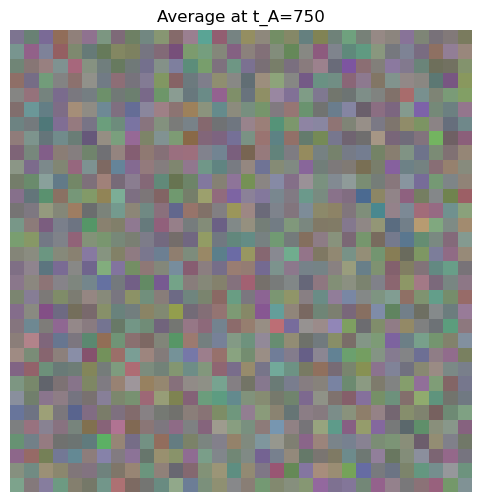

Verifying: 100%|██████████| 6/6 [02:21<00:00, 23.50s/it]

Contour distances per batch: [1.e+09 1.e+09 1.e+09 1.e+09 1.e+09 1.e+09]
Detection success (fraction below threshold): 0.00


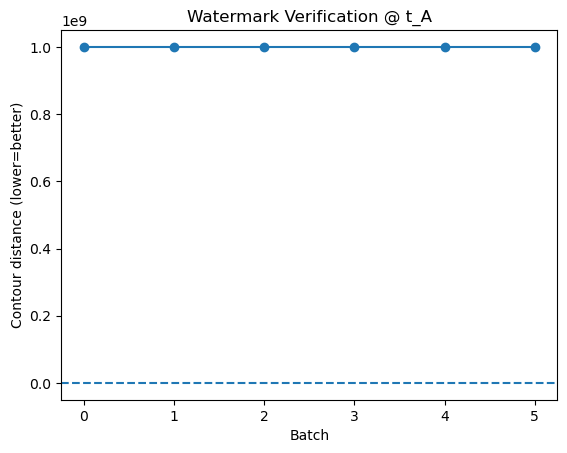

In [12]:

def tensor_to_uint8(img):
    """[N,C,H,W] in [0,1] -> uint8."""
    return (img.clamp(0,1) * 255).to(torch.uint8).detach().cpu()

def make_pattern_image_like(xA, value=255):
    """Use green channel for RGB, channel 0 for grayscale."""
    m = (xA[0] if xA.size(0) == 1 else xA[1])
    return (m.detach().cpu().numpy() > 0).astype(np.uint8) * value

def contour_similarity(img_u8, pattern_u8):
    """Canny + matchShapes distance (lower is better)."""
    img_blur = cv2.GaussianBlur(img_u8, (3,3), 0)
    pat_blur = cv2.GaussianBlur(pattern_u8, (3,3), 0)
    img_edges = cv2.Canny(img_blur, 50, 150)
    pat_edges = cv2.Canny(pat_blur, 50, 150)
    contours_img, _ = cv2.findContours(img_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_pat, _ = cv2.findContours(pat_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours_img) == 0 or len(contours_pat) == 0:
        return 1e9
    best = 1e9
    for ci in contours_img:
        for cp in contours_pat:
            d = cv2.matchShapes(ci, cp, cv2.CONTOURS_MATCH_I1, 0.0)
            best = min(best, d)
    return best

@torch.no_grad()
def verify_watermark(unet_like, scheduler, batches=6, batch_size=64, tA=None, gamma=0.8, threshold=0.3):
    """Repeat: sample→stop near tA→average→contour distance vs xA."""
    if tA is None: tA = int(tA_frac * T)
    pattern_u8 = make_pattern_image_like(xA, value=255)
    dists = []
    for _ in tqdm(range(batches), desc="Verifying"):
        _, xmid = sample_paper(unet_like, scheduler, n=batch_size, steps=cfg.sample_steps, capture_tA=tA, gamma=gamma)
        xavg = xmid.mean(dim=0, keepdim=True)
        xavg_u8 = tensor_to_uint8(xavg)[0,0].numpy()
        dists.append(contour_similarity(xavg_u8, pattern_u8))
    arr = np.array(dists, dtype=np.float32)
    success = float((arr < threshold).mean())
    return arr, success

# Show a single average at t_A
if mid is None:
    _, mid = sample_paper(sampler_unet, scheduler, n=cfg.verify_batch_size, steps=cfg.sample_steps, capture_tA=tA, gamma=cfg.gamma)
xavg = mid.mean(dim=0, keepdim=True)
show_grid_tensor(xavg, f"Average at t_A={tA}")

# Batch verification
distances, success = verify_watermark(sampler_unet, scheduler, batches=cfg.verify_batches, batch_size=cfg.verify_batch_size,
                                      tA=tA, gamma=cfg.gamma, threshold=cfg.contour_threshold)
print("Contour distances per batch:", distances)
print(f"Detection success (fraction below threshold): {success:.2f}")

plt.figure(); plt.plot(np.arange(len(distances)), distances, marker='o')
plt.axhline(cfg.contour_threshold, linestyle='--')
plt.xlabel("Batch"); plt.ylabel("Contour distance (lower=better)")
plt.title("Watermark Verification @ t_A"); plt.show()
